# Reading OSM datasets

Once you have a PBF file, the `OSM` reader turns it into [GeoPandas](https://geopandas.org/) GeoDataFrames. This section shows how to initialise the reader, read the main OSM datasets (street networks, buildings, POIs, landuse, natural elements and boundaries), limit reading to a bounding box, and read historical data.

**How to?**

- [Initialize the OSM reader](#initializing-the-pyrosm-osm-reader-object)
- [Read street networks](#read-street-networks)
- [Read buildings](#read-buildings)
- [Read Points of Interest (POI)](#read-points-of-interest)
- [Read landuse](#read-landuse)
- [Read natural](#read-natural)
- [Read boundaries](#read-boundaries)
- [Read OSM data with a custom filter](#read-osm-data-with-custom-filter)
- [Filter data based on a bounding box](#filtering-data-based-on-bounding-box)
- [Read historical OSM data](#read-historical-osm-data)
- [Reading large datasets with the out-of-core engine](#reading-large-datasets-with-the-out-of-core-engine)

## Initializing the Pyrosm OSM -reader object

When using `Pyrosm`, the first step is to initialize a specific reader object called `OSM` that is available from the `pyrosm` library: 

In [10]:
# Import the library
import pyrosm

# Print information about the basic usage of the `OSM` reader object
help(pyrosm.OSM.__init__)

Help on function __init__ in module pyrosm.pyrosm:

__init__(self, filepath, bounding_box=None)
    Initialize self.  See help(type(self)) for accurate signature.



As we can see from the documentation, the `OSM` object accepts two parameters:
  1. `filepath` which is the filepath to the PBF file (*.osm.pbf) which will be read (see info above how to get one), and
  2. `bounding_box` which is an optional parameter that can be used to filter OSM data geographically from specific area (see [here](#Filtering-data-based-on-bounding-box) for further details) 
  
The following shows how to initialize an `OSM` reader object using a test dataset that comes with Pyrosm, and which can be retrieved using a `get_data` function:

In [11]:
import pyrosm

# Get filepath to test PBF dataset
fp = pyrosm.get_data("test_pbf")
print("Filepath to test data:", fp)

# Initialize the OSM object 
osm = pyrosm.OSM(fp)

# See the type
print("Type of 'osm' instance: ", type(osm))

Filepath to test data: /Users/tenkanh2/Library/CloudStorage/OneDrive-AaltoUniversity/Documents/codes/uni/pyrosm/pyrosm/data/test.osm.pbf
Type of 'osm' instance:  <class 'pyrosm.pyrosm.OSM'>


As we can see, the test dataset lives in my case somewhere under the miniconda3 package, 
and the type of the `osm` instance is something called `pyrosm.pyrosm.OSM`. 

Notice that `osm` (lower case) is the actually initialized **reader instance** for the given PBF dataset that should always be used to make the calls for fetching different datasets from the OpenStreetMap PBF -file. Read further to see how things work.

## Read street networks

Pyrosm makes it easy to filter street networks using the `get_network()` method. 
You can parse streets separately for different travel modes by specifying the 
type of network using `network_type` -parameter.
The allowed network types are:

 - `walking` (default)
 - `cycling`
 - `driving`
 - `driving+service` (includes also [public service vehicles](https://wiki.openstreetmap.org/wiki/Key:psv))
 
The following shows how to read all drivable roads from OSM. Notice that from here on, we will import the `OSM` reader object directly from the package:

<Axes: >

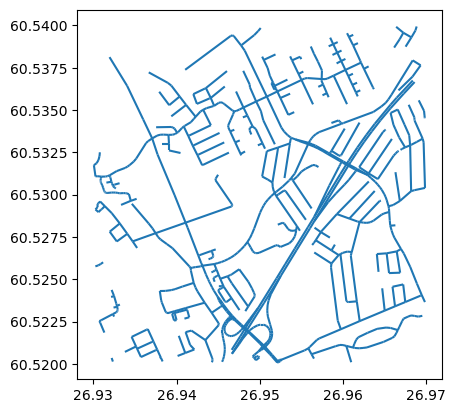

In [12]:
from pyrosm import OSM
from pyrosm import get_data

# Pyrosm comes with a couple of test datasets 
# that can be used straight away without
# downloading anything
fp = get_data("test_pbf")

# Initialize the OSM parser object
osm = OSM(fp)

# Read all drivable roads
# =======================
drive_net = osm.get_network(network_type="driving")
drive_net.plot()

The network contains various information that is parsed from the OSM data, and includes `length` column that contains information about the length of the road in meters (scroll right):

In [13]:
drive_net.head(2)

,access,bridge,highway,int_ref,lanes,lit,maxspeed,name,oneway,ref,service,surface,id,timestamp,version,tags,osm_type,geometry,length
0,NaN,NaN,secondary,NaN,2,NaN,80,Hurukselantie,NaN,357,NaN,asphalt,4732994,1441800394,23,"{""visible"":false,""name:fi"":""Hurukselantie""}",way,"MULTILINESTRING ((26.9431 60.5258, 26.94295 60...",1504.0
1,NaN,NaN,secondary,NaN,NaN,NaN,NaN,NaN,yes,170,NaN,NaN,5184588,1378828296,7,"{""visible"":false}",way,"MULTILINESTRING ((26.94778 60.52231, 26.94717 ...",242.0


Notice that each `way` in the network is represented as a MultiLineString geometry constructed from multiple road segments. This is how the data is represented by default in OSM. However, this differs if reading [nodes and edges](#read-nodes-and-edges-first-step): in that case each road segment is represented as a separate row in data (to improve connectivity). 

```{hint}

It is also possible to export network to routable graphs in various formats using `to_graph()` function (new in version 0.6.0). Read more from ["Export street networks to graph -section"](#export-street-networks-to-graph).

```

```{admonition} Understanding the "osm_type" -column values

pyrosm will create a column `osm_type` to the result which can contain values `node`, `way` or `relation`. These correspond to the three basic components of OpenStreetMap's conceptual data model of the physical world:

- nodes (points in space),
- ways (linear features and area boundaries), 
- relations (sometimes used to explain how other elements work together).

Hence, the "way" values in `osm_type` column **might not necessarily represent only** `LineString` **features**, as they can also be Polygons or LinearRings. 
If you want to know the geometry types of your data, you can access such information with geopandas by calling (gdf here represents a GeoDataFrame):
 `gdf["geometry_types"] = gdf.geom_type`   
 
Check [an example here](https://github.com/HTenkanen/pyrosm/issues/67#issuecomment-720482051) to see how to filter your GeoDataFrame based on specific geometry type.

```

## Read buildings



<Axes: >

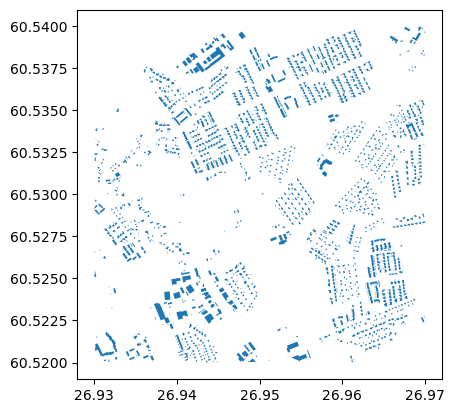

In [14]:
from pyrosm import OSM
from pyrosm import get_data
fp = get_data("test_pbf")
# Initialize the OSM parser object
osm = OSM(fp)
buildings = osm.get_buildings()
buildings.plot()

## Read Points of Interest

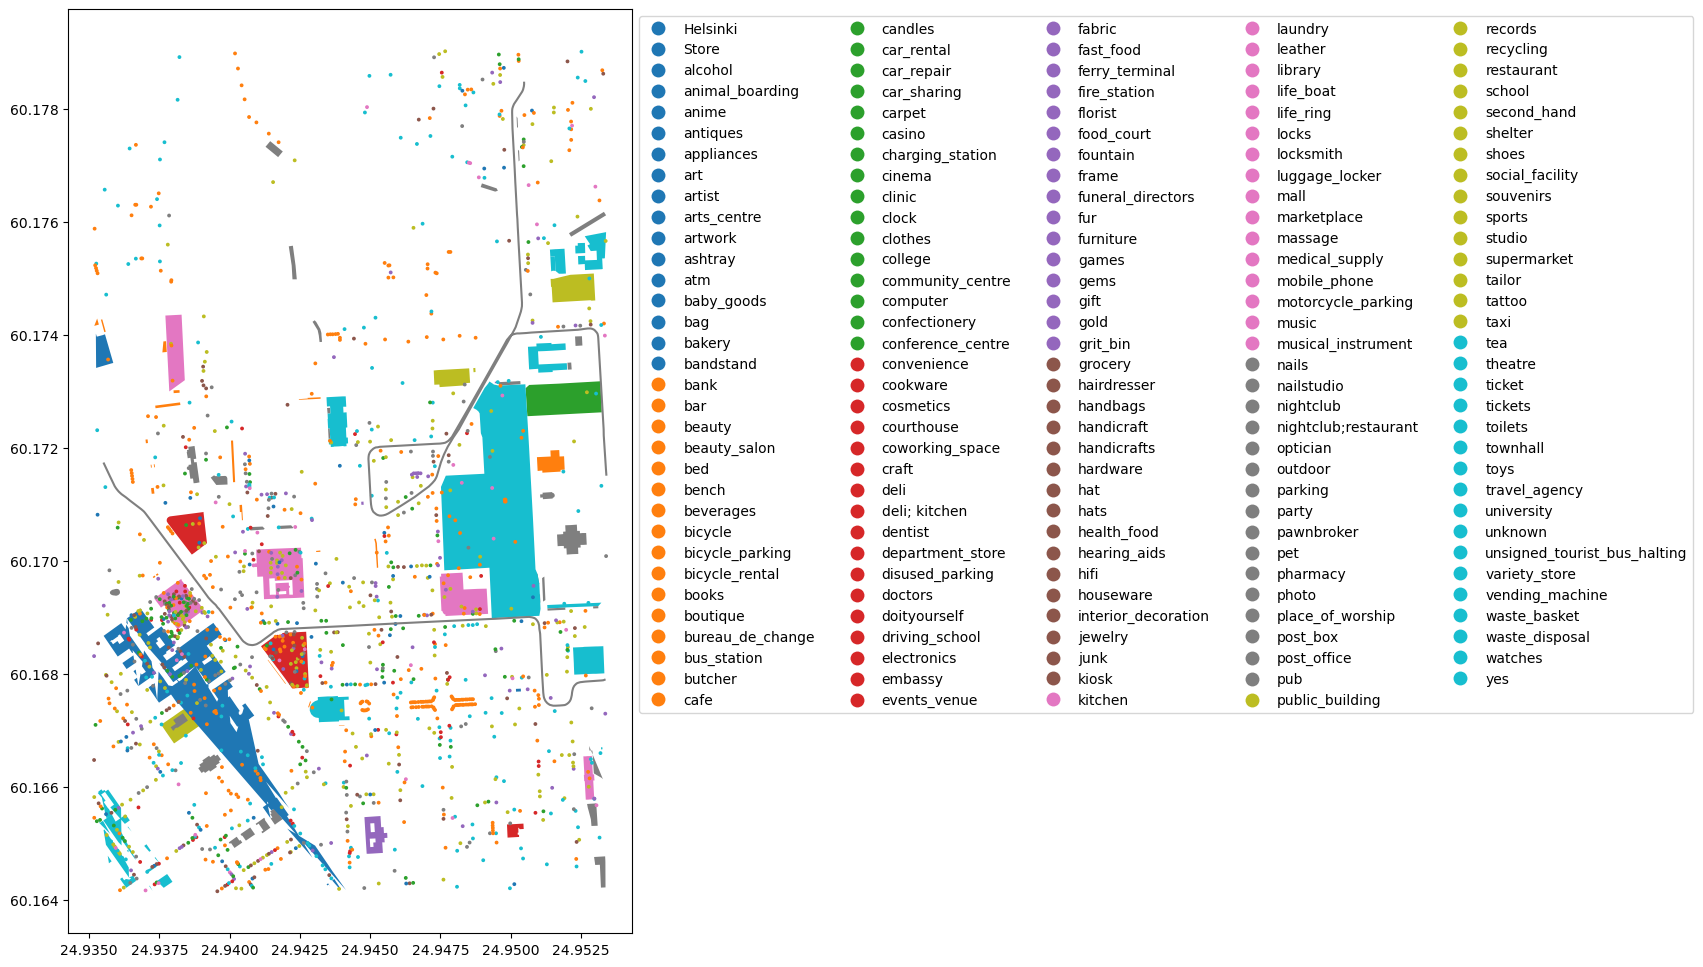

In [15]:
# Read POIs such as amenities and shops
# =====================================
from pyrosm import OSM
from pyrosm import get_data
fp = get_data("helsinki_pbf")
# Initialize the OSM parser object
osm = OSM(fp)

# By default pyrosm reads all elements having "amenity", "shop" or "tourism" tag
# Here, let's read only "amenity" and "shop" by applying a custom filter that
# overrides the default filtering mechanism
custom_filter = {'amenity': True, "shop": True}
pois = osm.get_pois(custom_filter=custom_filter)

# Gather info about POI type (combines the tag info from "amenity" and "shop")
pois["poi_type"] = pois["amenity"]
pois["poi_type"] = pois["poi_type"].fillna(pois["shop"])

# Plot
ax = pois.plot(column='poi_type', markersize=3, figsize=(12,12), legend=True, legend_kwds=dict(loc='upper left', ncol=5, bbox_to_anchor=(1, 1)))

## Read landuse

<Axes: >

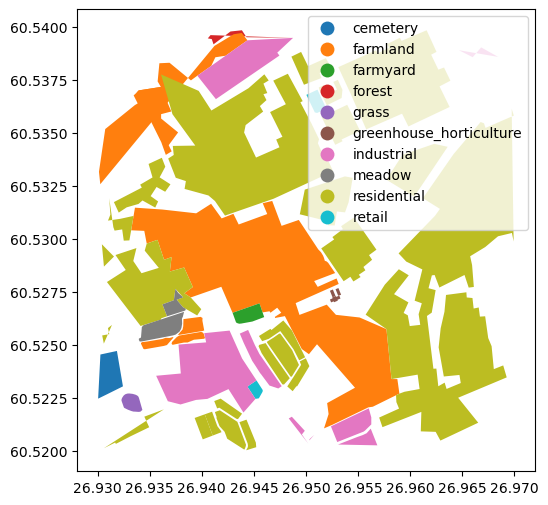

In [16]:
# Read landuse
# ============
from pyrosm import OSM
from pyrosm import get_data
fp = get_data("test_pbf")
# Initialize the OSM parser object
osm = OSM(fp)
landuse = osm.get_landuse()
landuse.plot(column='landuse', legend=True, figsize=(10,6))

## Read natural

<Axes: >

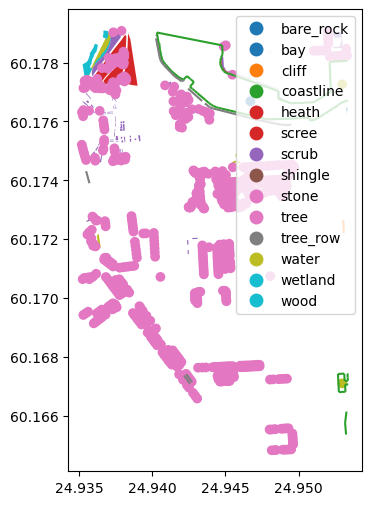

In [17]:
# Read natural
# ============
from pyrosm import OSM
from pyrosm import get_data
fp = get_data("helsinki_pbf")
# Initialize the OSM parser object
osm = OSM(fp)
natural = osm.get_natural()
natural.plot(column='natural', legend=True, figsize=(10,6))

## Read boundaries

`Pyrosm` supports reading boundaries such as administrative borders from PBF using `get_boundaries()` -function. 
By default, the function reads all `"administrative"` borders from the PBF. You can adjust the type of boundary that is parsed from PBF by modifying `boundary_type` -parameter. You can also search boundaries for specific name using `name` parameter:

Downloaded Protobuf data 'Helsinki_region.osm.pbf' (34.99 MB) to:
'/var/folders/f2/pgp09jl542zffhtrt2hx8zhh0000gp/T/pyrosm/Helsinki_region.osm.pbf'


<Axes: >

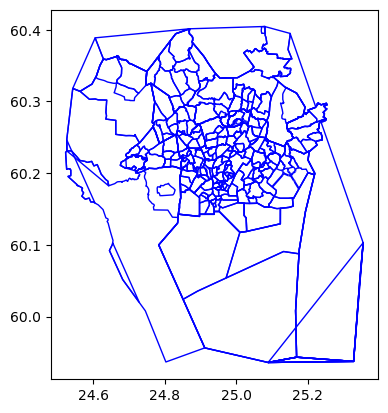

In [18]:
from pyrosm import OSM
from pyrosm import get_data
fp = get_data("helsinki_region_pbf")
osm = OSM(fp)

# Read all boundaries using the default settings
boundaries = osm.get_boundaries()
boundaries.plot(facecolor="none", edgecolor="blue")

The following shows how to search a specific boundary using the `name` -parameter.    

<Axes: >

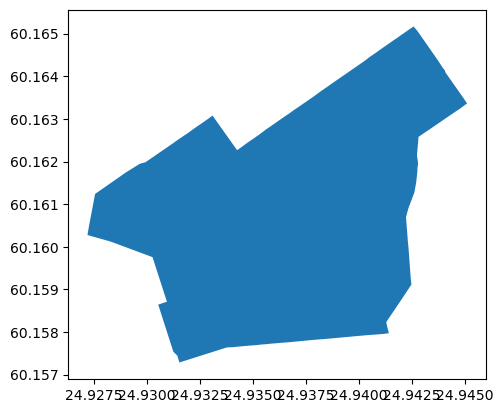

In [19]:
# Note: the following uses the same osm instance initialized above
selected_boundary = osm.get_boundaries(name="Punavuori")
selected_boundary.plot()

The name search functionality supports partial text search, meaning that e.g. a query `"vuori"` would return all elements where the work `"vuori"` is included in the name tag (such as "Punavuori"):

<Axes: >

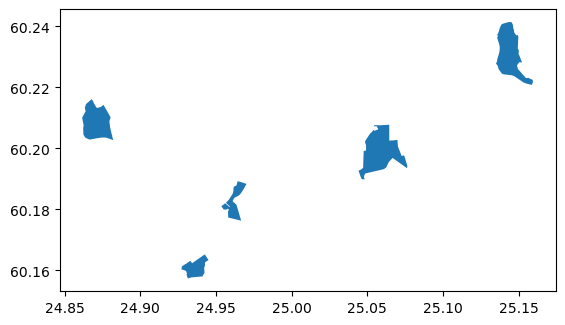

In [20]:
# Use a partial name "vuori" to look for data
selected_boundary = osm.get_boundaries(name="vuori")
selected_boundary.plot()

As we can see there were multiple boundaries in the data that included the word `"vuori"` in their name:

In [21]:
# Check all records that have the word "vuori" in their name
selected_boundary['name'].unique()

<StringArray>
['Punavuori', 'Munkkivuori', 'Roihuvuori', 'Mustavuori', 'Vilhonvuori']
Length: 5, dtype: str

It is also possible to search different kind of boundaries from the PBF.

Supported boundary types are:

   - `"administrative` (default)
   - `"national_park"`
   - `"political"`
   - `"postal_code"`
   - `"protected_area"`
   - `"aboriginal_lands"`
   - `"maritime"`
   - `"lot"`
   - `"parcel"`
   - `"tract"`
   - `"marker"`
   - `"all"`
    
Let's read all `"protected_area"` boundaries from the PBF:

<Axes: >

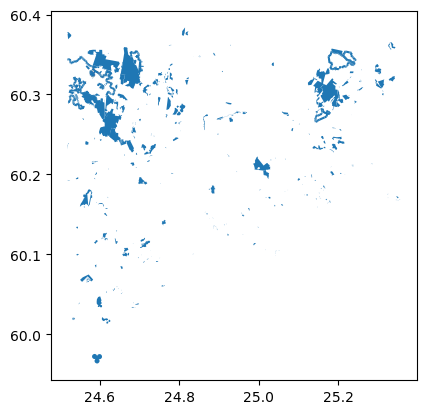

In [22]:
# Note: the following uses the same osm instance initialized above 
protected_areas = osm.get_boundaries(boundary_type="protected_area")
protected_areas.plot()

## Read OSM data with custom filter

Pyrosm also allows making custom queries. For example, to parse all transit related OSM elements you can use following approach 
and create a custom filter combining multiple criteria:

<Axes: >

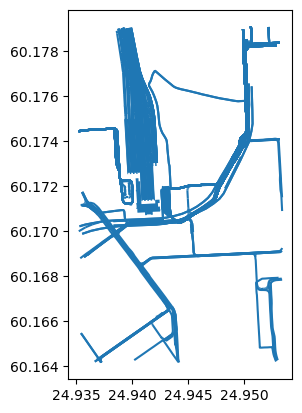

In [23]:
from pyrosm import OSM
from pyrosm import get_data
fp = get_data("helsinki_pbf")

# Initialize the OSM parser object with test data from Helsinki
osm = OSM(fp)

# Test reading all transit related data (bus, trains, trams, metro etc.)
# Exclude nodes (not keeping stops, etc.)
routes = ["bus", "ferry", "railway", "subway", "train", "tram", "trolleybus"]
rails = ["tramway", "light_rail", "rail", "subway", "tram"]
bus = ['yes']
transit = osm.get_data_by_custom_criteria(custom_filter={
                                        'route': routes,
                                        'railway': rails,
                                        'bus': bus,
                                        'public_transport': True},
                                        # Keep data matching the criteria above
                                        filter_type="keep",
                                        # Do not keep nodes (point data)    
                                        keep_nodes=False, 
                                        keep_ways=True, 
                                        keep_relations=True)
transit.plot()

Further information on how to make customized queries is available in [Parsing OSM data with custom queries](custom_filter.ipynb).

## Filtering data based on bounding box

Quite often one might be needing to extract only a subset of the whole OSM PBF file covering e.g. a specific region. `Pyrosm` provides an easy way to filter even larger PBF files using a bounding box (rectangular shape) or a more complex geometric feature (e.g. a Polygon). In the following, we will go through the process of extracting a small sample from the whole PBF dataset for specific area of interest. We will use a data dump from Greater London region and extract data covering the Borough of Camden.

In [23]:
from pyrosm import OSM, get_data

# Download a dataset for Greater London (update if exists in the temp already)
fp = get_data("Greater London", update=True)
osm = OSM(fp)

Downloaded Protobuf data 'greater-london-latest.osm.pbf' (55.49 MB) to:
'C:\Users\hentenka\AppData\Local\Temp\pyrosm\greater-london-latest.osm.pbf'


In [24]:
# Read buildings (takes ~30 seconds)
buildings = osm.get_buildings()
buildings.head(2)

,addr:city,addr:country,addr:full,addr:housenumber,addr:housename,addr:postcode,addr:place,addr:street,email,name,...,source,start_date,wikipedia,id,timestamp,version,tags,geometry,osm_type,changeset
0,None,None,None,None,None,None,None,None,None,Laurence House,...,None,None,None,2956186,1469657765,2,None,"POLYGON ((-0.02162 51.44472, -0.02033 51.44469...",way,NaN
1,None,None,None,None,Town Hall,SE6 4RU,None,Catford Broadway,None,Lewisham Town Hall,...,None,None,None,2956187,1504282380,5,None,"POLYGON ((-0.02110 51.44523, -0.02132 51.44508...",way,NaN


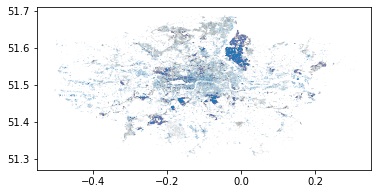

In [25]:
# Plot the buildings (will take awhile to plot)
buildings.plot()

Now have parsed quite a few buildings from the Greater London area (~488,000). 

Let's filter the data spatially and include only buildings from the Borough of Camden. There are a couple of ways how you can pass the bounding box information to the Pyrosm:

 1. You can specify the bounding box by **a list of x- and y-coordinates** (in decimal degrees) of the lower left corner and upper right corner of the geographical area (rectangular) that you want to keep as a result: **[minx, miny, maxx, maxy]** 
 2. You can also specify the bounding by passing a **Shapely Polygon, MultiPolygon or LinearRing** (all closed geometries supported) that can be used to filter the data with a more complex geographical features.
 
We will now use the boundary of the Camden Borough as our spatial filter. For finding the boundaries of Camden Borough is easy by utilizing the `get_boundaries()` -function and using the `name` parameter:

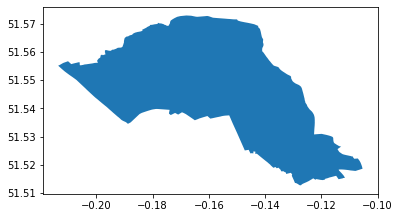

In [26]:
# Get the borough of Camden as our bounding box
bounding_box = osm.get_boundaries(name="London Borough of Camden")
bounding_box.plot()

Now we can initialize the `OSM` reader with the given bounding box that will then keep the data only from the areas that are **within** the given bounding box:

In [27]:
# Get the shapely geometry from GeoDataFrame
bbox_geom = bounding_box['geometry'].values[0]

# Initiliaze with bounding box
osm = OSM(fp, bounding_box=bbox_geom)

Now the bounding box information is stored in the attribute `bounding_box` that will be applied **every time** when an extract of the PBF (e.g. buildings, roads, etc.) is parsed:

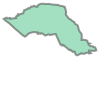

In [28]:
# Bounding box is now stored as an attribute 
osm.bounding_box

**Finally**, let's read the buildings now from the Camden Borough using our bounding box filter. Notice, that you do not need to make any changes to the actual `get_buildings()` call, as the bounding box information is read automatically from the osm instance (`osm.bounding_box`).

In [29]:
# Retrieve buildings for Camden
camden = osm.get_buildings()

Okay, now we have data for the Camden area! Let's take a look what it looks like on a map. 
Here, we will color the building based on how it has been tagged in the OSM:

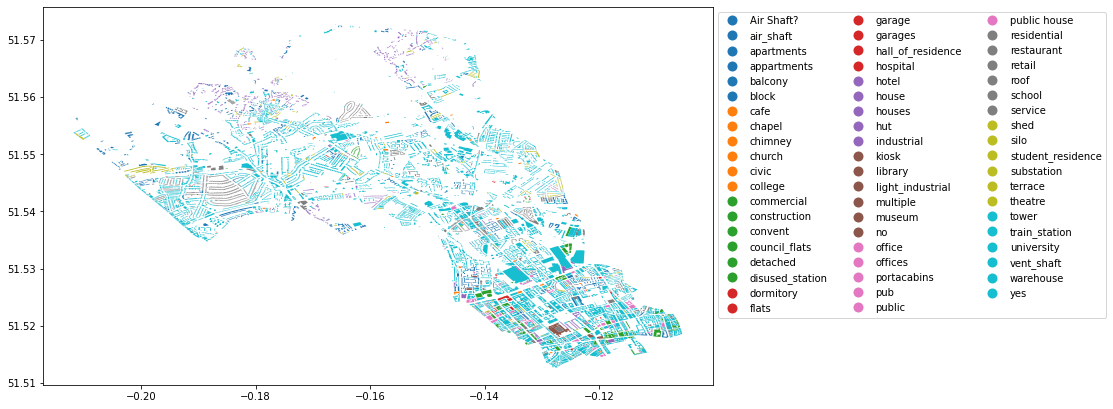

In [30]:
# Let's plot the buildings and specify colors according the type of the building
ax = camden.plot(column="building", figsize=(12,12), legend=True, legend_kwds=dict(loc='upper left', ncol=3, bbox_to_anchor=(1, 1)))

Great, now we can see that a subset of the data was taken according our bounding box coordinates.

We can utilize the same bounding box for filtering other datasets as well, which can be handy. Let's also filter the walkable roads from the same area:

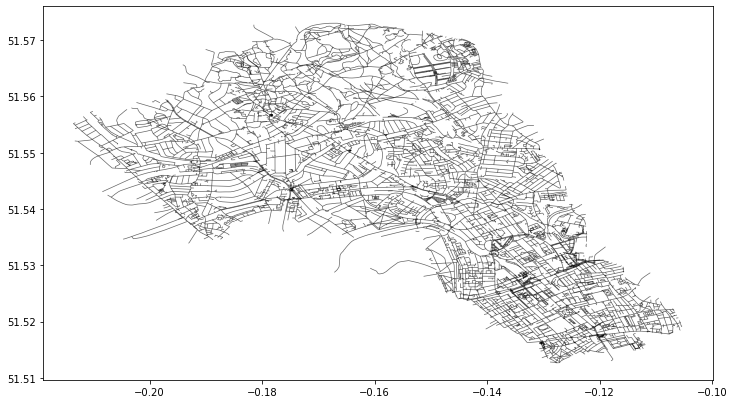

In [31]:
# Apply the same bounding box filter and retrieve walking network
walk = osm.get_network("walking")
walk.plot(color="k", figsize=(12,12), lw=0.7, alpha=0.6)

## Read historical OSM data

So far we have read data from regular `.osm.pbf` files, which contain a single snapshot of OpenStreetMap — the data as it looked at the moment the extract was made. OpenStreetMap also publishes **history files** (`.osh.pbf`), which keep *every* version of every element, together with the timestamp at which each version was edited. With a history file you can read the data as it looked at any chosen moment in time, which is useful for studying how an area has changed.

`pyrosm` recognises a history file automatically from its filename: as long as the path contains `osh.pbf`, the reader switches into history mode. You can then pass a `timestamp` to any of the `get_*` methods to choose the moment you want.

> **Note:** History files for whole regions can be downloaded from [Geofabrik](https://download.geofabrik.de/), but those downloads require logging in with an OpenStreetMap account, so `pyrosm` cannot fetch them for you. You point `pyrosm` at a file you have downloaded yourself. For this example we use a small bundled sample of central Helsinki.

Let's start by downloading the sample history file and initialising the reader:

In [24]:
from pyrosm import OSM, get_data

# Download a small sample history file for Helsinki
fp = get_data("helsinki_history_pbf")

# Initialise the reader; pyrosm detects the .osh.pbf file as a history file
osm = OSM(fp)

Downloaded Protobuf data 'Helsinki-sample.osh.pbf' (12.75 MB) to:
'/var/folders/f2/pgp09jl542zffhtrt2hx8zhh0000gp/T/pyrosm/Helsinki-sample.osh.pbf'


Now we can read the driving network as it looked at a chosen moment by passing a `timestamp`. The timestamp is interpreted in UTC and can be given either as a full date and time or as a date alone (in which case midnight at the start of that day is used):

In [25]:
# Read the driving network as it was at the start of 2019
net_2019 = osm.get_network(network_type="driving", timestamp="2019-01-01")
print(f"Edges in the 2019 snapshot: {len(net_2019)}")

Edges in the 2019 snapshot: 7267


For each element, `pyrosm` selects the most recent version edited *up to* the timestamp you gave. An element can therefore be older than the timestamp — its latest edit is kept — but versions edited *after* the timestamp are ignored. Elements that did not yet exist at that moment are left out entirely.

Let's read a later snapshot of the same network and compare:

In [26]:
# Read the same network as it was at the start of 2021
net_2021 = osm.get_network(network_type="driving", timestamp="2021-01-01")
print(f"Edges in the 2021 snapshot: {len(net_2021)}")

Edges in the 2021 snapshot: 8348


Here we see how the network in this part of Helsinki has changed between the two dates: the 2019 snapshot has 7,267 edges and the 2021 snapshot has 8,348, as mappers added and edited roads over time. A later snapshot typically contains at least as many features as an earlier one. By varying the `timestamp` you can reconstruct the state of the data at any point covered by the history file.

> **Be careful:** if you read from an `.osh.pbf` file *without* giving a `timestamp`, `pyrosm` falls back to the current UTC time and emits a warning, since there is no single "current" snapshot in a history file. It is important to understand what this fallback actually returns: it selects the most recent version of each element **that is present in the file**. A history file is a static download — it only contains edits up to the moment it was produced — so "the current time" does not give you today's live OpenStreetMap data, but the latest state captured in that particular file. The bundled Helsinki sample, for example, was produced back in 2021, so reading it without a `timestamp` reflects the situation in 2021, not the present day. Always pass an explicit `timestamp` when you read historical data, both so that your results are reproducible and so that it is clear which moment in time they represent.

## Reading large datasets with the out-of-core engine

By default the `OSM` reader loads the whole PBF into memory (`engine="in_memory"`), which is fast and convenient for city- and region-sized extracts. For larger files — up to whole countries — pyrosm also ships an **out-of-core** engine that decodes the PBF in a streaming fashion and keeps peak memory bounded. Select it with the `engine` parameter when you create the reader; every `get_*` method (and options such as `custom_filter` and `bounding_box`) works exactly as before and returns the same GeoDataFrames:

In [2]:
from pyrosm import OSM, get_data

fp = get_data("finland")

# Opt into the out-of-core engine
osm = OSM(fp, engine="out_of_core", workers="auto")
buildings = osm.get_buildings()

In [3]:
buildings.shape

(3145871, 43)

**Which engine should I use?** Keep the default `engine="in_memory"` for small and medium extracts, where it is fastest. Reach for `engine="out_of_core"` on large extracts (e.g. whole-country files) where reading everything into memory at once is impractical — it trades a little per-call overhead for a much lower memory ceiling.

**Result caching.** With `engine="out_of_core"`, each layer's result is written once to a GeoParquet file under a temporary directory, keyed by the source file and the read's parameters. Reading the same layer again — even in a later Python session — reuses that cached file instead of re-decoding the PBF, so repeat reads are near-instant. Caching uses the optional [`pyarrow`](https://arrow.apache.org/docs/python/) package; if `pyarrow` is not installed the out-of-core reader still works, but returns an in-memory GeoDataFrame without caching.

**Reading in parallel.** By default the out-of-core engine decodes on a single core, and the first read reports how many CPU cores are available. The simplest way to speed up a large read is `workers="auto"`, which lets pyrosm choose the worker count automatically — a single core for small files and multiple cores for large ones; pass `workers=N` for an explicit count (capped at the number of CPU cores your computer has).

Reading in parallel means pyrosm splits the work across several helper processes that run at the same time. On macOS and Windows, Python starts each helper by re-running your script from the top, so when you launch a parallel read from a standalone script you need to place it inside an `if __name__ == "__main__":` block. This is a standard Python guard that runs the code *only* when the file is launched directly, which stops each helper from starting its own read as it loads. Forgetting the guard is not fatal — pyrosm simply falls back to reading on a single core and prints a warning:

```python
from pyrosm import OSM

if __name__ == "__main__":
    osm = OSM("finland-latest.osm.pbf", engine="out_of_core", workers="auto")
    buildings = osm.get_buildings()

```

Forgetting the guard is not fatal — pyrosm simply falls back to reading on a single core and prints a warning. The guard matters only when a read actually runs in parallel (e.g. `workers="auto"` on a large file, or an explicit `workers` > 1) from a standalone script (e.g. `my_analysis.py`); the default single-core read and interactive sessions such as running the code inside a Jupyter Notebook do not need a guard.